In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)

df = pd.read_csv('../data/raw/skill_builder_data.csv', 
                 encoding='latin-1', 
                 low_memory=False)

print(f"Shape: {df.shape}")
print(f"Columns: {df.shape[1]}")
df.head()

Shape: (525534, 30)
Columns: 30


,order_id,assignment_id,user_id,assistment_id,problem_id,original,correct,attempt_count,ms_first_response,tutor_mode,answer_type,sequence_id,student_class_id,position,type,base_sequence_id,skill_id,skill_name,teacher_id,school_id,hint_count,hint_total,overlap_time,template_id,answer_id,answer_text,first_action,bottom_hint,opportunity,opportunity_original
0,33022537,277618,64525,33139,51424,1,1,1,32454,tutor,algebra,5948,13241,126,MasterySection,5948,1.0,Box and Whisker,22763,73,0,3,32454,30799,NaN,26,0,NaN,1,1.0
1,33022709,277618,64525,33150,51435,1,1,1,4922,tutor,algebra,5948,13241,126,MasterySection,5948,1.0,Box and Whisker,22763,73,0,3,4922,30799,NaN,55,0,NaN,2,2.0
2,35450204,220674,70363,33159,51444,1,0,2,25390,tutor,algebra,5948,11816,22,MasterySection,5948,1.0,Box and Whisker,22763,73,0,3,42000,30799,NaN,88,0,NaN,1,1.0
3,35450295,220674,70363,33110,51395,1,1,1,4859,tutor,algebra,5948,11816,22,MasterySection,5948,1.0,Box and Whisker,22763,73,0,3,4859,30059,NaN,41,0,NaN,2,2.0
4,35450311,220674,70363,33196,51481,1,0,14,19813,tutor,algebra,5948,11816,22,MasterySection,5948,1.0,Box and Whisker,22763,73,3,4,124564,30060,NaN,65,0,0.0,3,3.0


In [2]:
# What columns do we have?
print("Columns:")
print(df.columns.tolist())
print()

# How many unique students and skills?
print(f"Unique students: {df['user_id'].nunique():,}")
print(f"Unique skills: {df['skill_name'].nunique():,}")
print(f"Total interactions: {len(df):,}")
print()

# Missing values in the columns we care about
print("Missing values in key columns:")
print(df[['user_id', 'skill_name', 'skill_id', 'correct', 'order_id']].isnull().sum())

Columns:
['order_id', 'assignment_id', 'user_id', 'assistment_id', 'problem_id', 'original', 'correct', 'attempt_count', 'ms_first_response', 'tutor_mode', 'answer_type', 'sequence_id', 'student_class_id', 'position', 'type', 'base_sequence_id', 'skill_id', 'skill_name', 'teacher_id', 'school_id', 'hint_count', 'hint_total', 'overlap_time', 'template_id', 'answer_id', 'answer_text', 'first_action', 'bottom_hint', 'opportunity', 'opportunity_original']

Unique students: 4,217
Unique skills: 110
Total interactions: 525,534

Missing values in key columns:
user_id           0
skill_name    78690
skill_id      66326
correct           0
order_id          0
dtype: int64


In [3]:
# What values does 'correct' actually contain?
print("Distribution of 'correct' values:")
print(df['correct'].value_counts(dropna=False))
print()

# What proportion of attempts are correct?
print(f"Overall correct rate: {df['correct'].mean():.2%}")

Distribution of 'correct' values:
correct
1    357085
0    168449
Name: count, dtype: int64

Overall correct rate: 67.95%


In [4]:
# How are attempts distributed across skills?
skill_counts = df['skill_name'].value_counts()

print(f"Total skills: {len(skill_counts)}")
print(f"Most attempts on a single skill: {skill_counts.max():,}")
print(f"Fewest attempts on a single skill: {skill_counts.min():,}")
print(f"Median attempts per skill: {skill_counts.median():,.0f}")
print()

print("Top 10 most-attempted skills:")
print(skill_counts.head(10))
print()

print("Bottom 10 least-attempted skills:")
print(skill_counts.tail(10))

Total skills: 110
Most attempts on a single skill: 24,253
Fewest attempts on a single skill: 5
Median attempts per skill: 1,832

Top 10 most-attempted skills:
skill_name
Equation Solving Two or Fewer Steps         24253
Percent Of                                  22931
Addition and Subtraction Integers           22895
Conversion of Fraction Decimals Percents    20992
Volume Rectangular Prism                    19489
Venn Diagram                                18275
Volume Cylinder                             13734
Multiplication and Division Integers        13159
Area Rectangle                              12934
Addition and Subtraction Fractions          11334
Name: count, dtype: int64

Bottom 10 least-attempted skills:
skill_name
Slope                                            89
Percent Discount                                 47
Computation with Real Numbers                    42
Interpreting Coordinate Graphs                   33
Midpoint                                         3

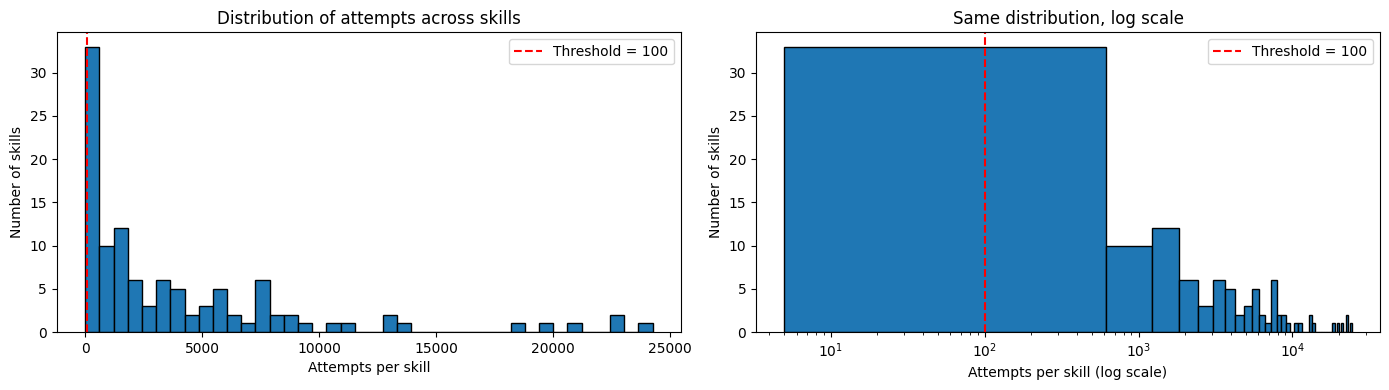


Filtering at minimum 100 attempts per skill:
  Skills kept:    95 / 110
  Skills dropped: 15
  Interactions kept:    446,084 / 525,534


In [5]:
# Plot the distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Linear scale
axes[0].hist(skill_counts.values, bins=40, edgecolor='black')
axes[0].set_xlabel('Attempts per skill')
axes[0].set_ylabel('Number of skills')
axes[0].set_title('Distribution of attempts across skills')
axes[0].axvline(100, color='red', linestyle='--', label='Threshold = 100')
axes[0].legend()

# Log scale (better view of the long tail)
axes[1].hist(skill_counts.values, bins=40, edgecolor='black')
axes[1].set_xscale('log')
axes[1].set_xlabel('Attempts per skill (log scale)')
axes[1].set_ylabel('Number of skills')
axes[1].set_title('Same distribution, log scale')
axes[1].axvline(100, color='red', linestyle='--', label='Threshold = 100')
axes[1].legend()

plt.tight_layout()
plt.show()

# Effect of filtering
threshold = 100
keep_skills = skill_counts[skill_counts >= threshold].index
drop_skills = skill_counts[skill_counts < threshold].index

print(f"\nFiltering at minimum {threshold} attempts per skill:")
print(f"  Skills kept:    {len(keep_skills)} / {len(skill_counts)}")
print(f"  Skills dropped: {len(drop_skills)}")
print(f"  Interactions kept:    {df[df['skill_name'].isin(keep_skills)].shape[0]:,} / {len(df):,}")


In [6]:
# Verify the source of dropped interactions
total = len(df)
missing_skill = df['skill_name'].isnull().sum()
in_dropped_skills = df[df['skill_name'].isin(drop_skills)].shape[0]
in_kept_skills = df[df['skill_name'].isin(keep_skills)].shape[0]

print(f"Total interactions:                 {total:,}")
print(f"Missing skill_name (unusable):      {missing_skill:,}")
print(f"In dropped low-data skills:         {in_dropped_skills:,}")
print(f"In kept skills (our training set):  {in_kept_skills:,}")
print(f"Sum check: {missing_skill + in_dropped_skills + in_kept_skills:,}")

Total interactions:                 525,534
Missing skill_name (unusable):      78,690
In dropped low-data skills:         760
In kept skills (our training set):  446,084
Sum check: 525,534


In [7]:
# Filter to our clean working set
clean_df = df[df['skill_name'].isin(keep_skills)].copy()

# Total attempts per student
attempts_per_student = clean_df.groupby('user_id').size()

print("Attempts per student:")
print(f"  Mean:   {attempts_per_student.mean():.1f}")
print(f"  Median: {attempts_per_student.median():.0f}")
print(f"  Min:    {attempts_per_student.min()}")
print(f"  Max:    {attempts_per_student.max():,}")
print()

# How many students have very few attempts?
print(f"Students with < 10 attempts:  {(attempts_per_student < 10).sum():,}")
print(f"Students with < 5 attempts:   {(attempts_per_student < 5).sum():,}")
print()

# Attempts per (student, skill) pair — this is what BKT actually trains on
attempts_per_pair = clean_df.groupby(['user_id', 'skill_name']).size()

print("Attempts per (student, skill) pair:")
print(f"  Mean:   {attempts_per_pair.mean():.1f}")
print(f"  Median: {attempts_per_pair.median():.0f}")
print(f"  Pairs with only 1 attempt: {(attempts_per_pair == 1).sum():,} ({(attempts_per_pair == 1).mean():.1%})")

Attempts per student:
  Mean:   108.1
  Median: 24
  Min:    1
  Max:    6,157

Students with < 10 attempts:  1,038
Students with < 5 attempts:   459

Attempts per (student, skill) pair:
  Mean:   11.5
  Median: 5
  Pairs with only 1 attempt: 7,296 (18.7%)


In [8]:
min_student_attempts = 5

# Find students who meet the threshold
student_attempt_counts = clean_df.groupby('user_id').size()
keep_students = student_attempt_counts[student_attempt_counts >= min_student_attempts].index

# Apply filter
final_df = clean_df[clean_df['user_id'].isin(keep_students)].copy()

print(f"Filtering at minimum {min_student_attempts} attempts per student:")
print(f"  Students kept:     {len(keep_students):,} / {clean_df['user_id'].nunique():,}")
print(f"  Students dropped:  {clean_df['user_id'].nunique() - len(keep_students):,}")
print()
print(f"Final training dataset:")
print(f"  Interactions: {len(final_df):,}")
print(f"  Students:     {final_df['user_id'].nunique():,}")
print(f"  Skills:       {final_df['skill_name'].nunique()}")
print(f"  Correct rate: {final_df['correct'].mean():.2%}")

Filtering at minimum 5 attempts per student:
  Students kept:     3,669 / 4,128
  Students dropped:  459

Final training dataset:
  Interactions: 445,009
  Students:     3,669
  Skills:       95
  Correct rate: 69.57%


In [9]:
import os

# Sort by student, then chronologically within each student's history
final_df = final_df.sort_values(['user_id', 'order_id']).reset_index(drop=True)

# Verify the sort
sample_student = final_df['user_id'].iloc[0]
sample_history = final_df[final_df['user_id'] == sample_student][['order_id', 'skill_name', 'correct']].head(10)
print(f"Sample chronological history for student {sample_student}:")
print(sample_history)
print()

# Make sure processed data folder exists
os.makedirs('../data/processed', exist_ok=True)

# Save only the columns BKT needs
output_cols = ['user_id', 'skill_name', 'correct', 'order_id']
final_df[output_cols].to_csv('../data/processed/bkt_training_data.csv', index=False)

print(f"Saved cleaned data to: data/processed/bkt_training_data.csv")
print(f"File size: {os.path.getsize('../data/processed/bkt_training_data.csv') / 1024 / 1024:.1f} MB")

Sample chronological history for student 14:
   order_id    skill_name  correct
0  21617623  Circle Graph        0
1  21617623    Percent Of        0
2  21617632  Circle Graph        1
3  21617632    Percent Of        1
4  21617641  Circle Graph        0
5  21617641    Percent Of        0
6  21617650  Circle Graph        0
7  21617650    Percent Of        0
8  21617659  Circle Graph        0
9  21617659    Percent Of        0

Saved cleaned data to: data/processed/bkt_training_data.csv
File size: 17.6 MB


In [10]:
# Summary statistics for presentation reference
print("=" * 60)
print("BKT TRAINING DATASET — SUMMARY")
print("=" * 60)
print()
print("Source: ASSISTments 2009-2010 Skill Builder")
print("Domain: K-12 Mathematics")
print()
print("DATA PIPELINE:")
print(f"  Raw interactions:        {525534:>10,}")
print(f"  After cleaning:          {len(final_df):>10,}")
print(f"  Retention:               {len(final_df)/525534:>10.1%}")
print()
print("FINAL DATASET:")
print(f"  Students:                {final_df['user_id'].nunique():>10,}")
print(f"  Skills (concepts):       {final_df['skill_name'].nunique():>10,}")
print(f"  Total interactions:      {len(final_df):>10,}")
print(f"  Mean attempts/student:   {final_df.groupby('user_id').size().mean():>10.1f}")
print(f"  Mean attempts/skill:     {final_df.groupby('skill_name').size().mean():>10.1f}")
print(f"  Overall correct rate:    {final_df['correct'].mean():>10.1%}")
print()
print("FILTERING APPLIED:")
print(f"  Min attempts per skill:    100")
print(f"  Min attempts per student:    5")
print(f"  Required: non-null skill_name")
print()
print("=" * 60)

BKT TRAINING DATASET — SUMMARY

Source: ASSISTments 2009-2010 Skill Builder
Domain: K-12 Mathematics

DATA PIPELINE:
  Raw interactions:           525,534
  After cleaning:             445,009
  Retention:                    84.7%

FINAL DATASET:
  Students:                     3,669
  Skills (concepts):               95
  Total interactions:         445,009
  Mean attempts/student:        121.3
  Mean attempts/skill:         4684.3
  Overall correct rate:         69.6%

FILTERING APPLIED:
  Min attempts per skill:    100
  Min attempts per student:    5
  Required: non-null skill_name



In [11]:
import sys
sys.path.append('..')  # so we can import from bkt/

from bkt.train import load_training_data, train_bkt

# Load full data
df = load_training_data()

# Test on just 3 skills first
test_skills = df['skill_name'].value_counts().head(3).index.tolist()
test_df = df[df['skill_name'].isin(test_skills)]
print(f"Testing on {len(test_df):,} interactions across {len(test_skills)} skills")
print(f"Skills: {test_skills}")

# Quick train
test_model = train_bkt(test_df, num_fits=1)
print(test_model.params())

2026-04-29 17:01:43,075 [INFO] Loaded 445,009 interactions, 3,669 students, 95 skills
2026-04-29 17:01:43,136 [INFO] Training BKT model (num_fits=1, seed=42)...
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyBKT\fit\M_step.py:61: RuntimeWarning: invalid value encountered in divide
  model['pi_0'] = init_softcounts[:] / np.sum(init_softcounts[:])
2026-04-29 17:01:43,269 [INFO] Training complete.


Testing on 69,903 interactions across 3 skills
Skills: ['Equation Solving Two or Fewer Steps', 'Addition and Subtraction Integers', 'Percent Of']
                                                      value
skill                               param   class          
Percent Of                          prior   default     NaN
                                    learns  default 1.00000
                                    guesses default 0.50000
                                    slips   default 0.50000
                                    forgets default 0.00000
Equation Solving Two or Fewer Steps prior   default     NaN
                                    learns  default 1.00000
                                    guesses default 0.50000
                                    slips   default 0.50000
                                    forgets default 0.00000
Addition and Subtraction Integers   prior   default     NaN
                                    learns  default 1.00000
              

In [12]:
print("Dtypes:")
print(test_df.dtypes)
print()
print("Sample rows:")
print(test_df.head())
print()
print("Any NaN in key columns?")
print(test_df[['user_id', 'skill_name', 'correct']].isnull().sum())
print()
print("Unique values in 'correct':")
print(test_df['correct'].unique())

Dtypes:
user_id       int64
skill_name      str
correct       int64
order_id      int64
dtype: object

Sample rows:
   user_id  skill_name  correct  order_id
1       14  Percent Of        0  21617623
3       14  Percent Of        1  21617632
5       14  Percent Of        0  21617641
7       14  Percent Of        0  21617650
9       14  Percent Of        0  21617659

Any NaN in key columns?
user_id       0
skill_name    0
correct       0
dtype: int64

Unique values in 'correct':
[0 1]


In [13]:
test_model = train_bkt(test_df, num_fits=5)
print(test_model.params())

2026-04-29 17:07:53,698 [INFO] Training BKT model (num_fits=5, seed=42)...
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyBKT\fit\M_step.py:61: RuntimeWarning: invalid value encountered in divide
  model['pi_0'] = init_softcounts[:] / np.sum(init_softcounts[:])
2026-04-29 17:07:53,809 [INFO] Training complete.


                                                      value
skill                               param   class          
Percent Of                          prior   default     NaN
                                    learns  default 1.00000
                                    guesses default 0.50000
                                    slips   default 0.50000
                                    forgets default 0.00000
Equation Solving Two or Fewer Steps prior   default     NaN
                                    learns  default 1.00000
                                    guesses default 0.50000
                                    slips   default 0.50000
                                    forgets default 0.00000
Addition and Subtraction Integers   prior   default     NaN
                                    learns  default 1.00000
                                    guesses default 0.50000
                                    slips   default 0.50000
                                    forg

In [2]:
import sys
print(f"Python version: {sys.version}")
print(f"Python path: {sys.executable}")

import pyBKT
print(f"pyBKT location: {pyBKT.__file__}")

Python version: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Python path: c:\Users\Lenovo\AppData\Local\Python\pythoncore-3.11-64\python.exe


ModuleNotFoundError: No module named 'pyBKT'

In [3]:
import sys
print(f"Python version: {sys.version}")
print(f"Python path: {sys.executable}")

Python version: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Python path: c:\Users\Lenovo\AppData\Local\Python\pythoncore-3.11-64\python.exe


In [1]:
import sys
print(f"Python path: {sys.executable}")
import pyBKT
print(f"pyBKT location: {pyBKT.__file__}")

Python path: c:\Users\Lenovo\Documents\Research\meta_agent_pro\venv\Scripts\python.exe
pyBKT location: c:\Users\Lenovo\Documents\Research\meta_agent_pro\venv\Lib\site-packages\pyBKT\__init__.py


In [2]:
import sys
sys.path.append('..')

from bkt.train import load_training_data, train_bkt

# Load full data
df = load_training_data()

# Test on just 3 skills first
test_skills = df['skill_name'].value_counts().head(3).index.tolist()
test_df = df[df['skill_name'].isin(test_skills)]
print(f"Testing on {len(test_df):,} interactions across {len(test_skills)} skills")
print(f"Skills: {test_skills}")

# Quick train with multiple fits to avoid local optima
test_model = train_bkt(test_df, num_fits=5)
print(test_model.params())

2026-04-29 18:31:14,803 [INFO] Loaded 445,009 interactions, 3,669 students, 95 skills
2026-04-29 18:31:14,851 [INFO] Training BKT model (num_fits=5, seed=42)...
c:\Users\Lenovo\Documents\Research\meta_agent_pro\venv\Lib\site-packages\pyBKT\fit\M_step.py:61: RuntimeWarning: invalid value encountered in divide
  model['pi_0'] = init_softcounts[:] / np.sum(init_softcounts[:])
2026-04-29 18:31:14,944 [INFO] Training complete.


Testing on 69,903 interactions across 3 skills
Skills: ['Equation Solving Two or Fewer Steps', 'Addition and Subtraction Integers', 'Percent Of']
                                                      value
skill                               param   class          
Percent Of                          prior   default     NaN
                                    learns  default 1.00000
                                    guesses default 0.50000
                                    slips   default 0.50000
                                    forgets default 0.00000
Equation Solving Two or Fewer Steps prior   default     NaN
                                    learns  default 1.00000
                                    guesses default 0.50000
                                    slips   default 0.50000
                                    forgets default 0.00000
Addition and Subtraction Integers   prior   default     NaN
                                    learns  default 1.00000
              

In [1]:
import numpy
print(f"numpy version: {numpy.__version__}")
print(f"numpy location: {numpy.__file__}")

numpy version: 1.26.4
numpy location: c:\Users\Lenovo\Documents\Research\meta_agent_pro\venv\Lib\site-packages\numpy\__init__.py


In [1]:
import sys
sys.path.append('..')

# Force reimport in case the module is cached
import importlib
import bkt.predict
importlib.reload(bkt.predict)
from bkt.predict import BKTPredictor

predictor = BKTPredictor.load()

# Test 1: A struggling student on Percent Of
print("Test 1 — Struggling student on 'Percent Of':")
attempts = [0, 0, 0, 1, 0]
mastery = predictor.predict('Percent Of', attempts)
trajectory = predictor.predict_trajectory('Percent Of', attempts)
print(f"  Final mastery: {mastery:.3f}")
print(f"  Trajectory:    {[f'{p:.3f}' for p in trajectory]}")
print()

# Test 2: A strong student on the same skill
print("Test 2 — Strong student on 'Percent Of':")
attempts = [1, 1, 1, 1, 1]
mastery = predictor.predict('Percent Of', attempts)
trajectory = predictor.predict_trajectory('Percent Of', attempts)
print(f"  Final mastery: {mastery:.3f}")
print(f"  Trajectory:    {[f'{p:.3f}' for p in trajectory]}")
print()

# Test 3: Recovery pattern - struggle then succeed
print("Test 3 — Recovery on 'Equation Solving Two or Fewer Steps':")
attempts = [0, 0, 1, 1, 1]
mastery = predictor.predict('Equation Solving Two or Fewer Steps', attempts)
trajectory = predictor.predict_trajectory('Equation Solving Two or Fewer Steps', attempts)
print(f"  Final mastery: {mastery:.3f}")
print(f"  Trajectory:    {[f'{p:.3f}' for p in trajectory]}")

Test 1 — Struggling student on 'Percent Of':
  Final mastery: 0.013
  Trajectory:    ['0.059', '0.013', '0.013', '0.013', '0.037', '0.013']

Test 2 — Strong student on 'Percent Of':
  Final mastery: 0.651
  Trajectory:    ['0.059', '0.116', '0.207', '0.337', '0.495', '0.651']

Test 3 — Recovery on 'Equation Solving Two or Fewer Steps':
  Final mastery: 0.782
  Trajectory:    ['0.642', '0.402', '0.212', '0.395', '0.606', '0.782']


In [2]:
import sys
sys.path.append('..')

import importlib
import db.database
importlib.reload(db.database)
from db.database import initialise_database, get_connection

initialise_database()

with get_connection() as conn:
    tables = conn.execute(
        "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name"
    ).fetchall()
    print("Tables in database:")
    for t in tables:
        print(f"  - {t['name']}")
    
    conn.execute("INSERT OR IGNORE INTO students (student_id) VALUES (?)", ("test_student_1",))
    
    students = conn.execute("SELECT * FROM students").fetchall()
    print(f"\nStudents in DB: {len(students)}")
    for s in students:
        print(f"  - {s['student_id']} (created: {s['created_at']})")

Tables in database:
  - attempts
  - mastery
  - sessions
  - sqlite_sequence
  - students

Students in DB: 1
  - test_student_1 (created: 2026-05-04 13:03:23)


In [ ]:
import sys
sys.path.append('..')

import importlib
import core.knowledge_graph
importlib.reload(core.knowledge_graph)
from core.knowledge_graph import KnowledgeGraph

kg = KnowledgeGraph()

# Simulate a tutoring session
session_summary = kg.process_session(
    student_id="alice_001",
    attempts=[
        {"skill": "Percent Of", "correct": 0},
        {"skill": "Percent Of", "correct": 0},
        {"skill": "Percent Of", "correct": 1},
        {"skill": "Percent Of", "correct": 1},
        {"skill": "Equation Solving Two or Fewer Steps", "correct": 1},
        {"skill": "Equation Solving Two or Fewer Steps", "correct": 1},
    ],
)

print(f"Session ID: {session_summary['session_id']}")
print(f"Skills updated: {session_summary['skills_updated']}")
print(f"\nKnowledge graph for alice_001:")
for entry in session_summary['graph']:
    p = entry['mastery_probability']
    label = entry['mastery_label']
    bar = '█' * int(p * 20)
    print(f"  {entry['skill']:<40} {p:.3f}  [{label}]  {bar}")

In [ ]:
# Simulate a second session for the same student — Alice has improved on Percent Of
session_2 = kg.process_session(
    student_id="alice_001",
    attempts=[
        {"skill": "Percent Of", "correct": 1},
        {"skill": "Percent Of", "correct": 1},
        {"skill": "Percent Of", "correct": 1},
        {"skill": "Percent Of", "correct": 1},
    ],
)

print(f"Session ID: {session_2['session_id']}")
print(f"\nUpdated knowledge graph for alice_001:")
for entry in session_2['graph']:
    p = entry['mastery_probability']
    label = entry['mastery_label']
    bar = '█' * int(p * 20)
    print(f"  {entry['skill']:<40} {p:.3f}  [{label}]  {bar}")

In [1]:
import sys
sys.path.append('..')

import importlib
import core.knowledge_graph
import core.learning_path
importlib.reload(core.knowledge_graph)
importlib.reload(core.learning_path)
from core.knowledge_graph import KnowledgeGraph
from core.learning_path import generate_learning_path, format_path_text

kg = KnowledgeGraph()

kg.process_session(
    student_id="bob_007",
    attempts=[
        {"skill": "Fraction Of", "correct": 1},
        {"skill": "Fraction Of", "correct": 1},
        {"skill": "Fraction Of", "correct": 1},
        {"skill": "Equation Solving Two or Fewer Steps", "correct": 1},
        {"skill": "Equation Solving Two or Fewer Steps", "correct": 0},
        {"skill": "Equation Solving Two or Fewer Steps", "correct": 1},
        {"skill": "Percent Of", "correct": 0},
        {"skill": "Percent Of", "correct": 0},
        {"skill": "Percent Of", "correct": 0},
    ],
)

graph = kg.get_student_graph("bob_007")
path = generate_learning_path(graph)

print(format_path_text(path, student_id="bob_007"))
print(f"\nSummary: {path['summary']}")

Learning path for student: bob_007

REVISE URGENTLY (1):
  - Percent Of                               P=0.013

LEARN NEXT (0):

ALREADY STRONG (2):
  - Fraction Of                              P=1.000
  - Equation Solving Two or Fewer Steps      P=0.781

Summary: {'revise_count': 1, 'learn_next_count': 0, 'strong_count': 2, 'regression_count': 0}


In [2]:
# Bob comes back next session and bombs Fraction Of
kg.process_session(
    student_id="bob_007",
    attempts=[
        {"skill": "Fraction Of", "correct": 0},
        {"skill": "Fraction Of", "correct": 0},
        {"skill": "Fraction Of", "correct": 0},
        {"skill": "Fraction Of", "correct": 0},
    ],
)

graph = kg.get_student_graph("bob_007")
path = generate_learning_path(graph)

print(format_path_text(path, student_id="bob_007"))
print(f"\nSummary: {path['summary']}")

# Show regression details
if path['regressions']:
    print("\n⚠️  REGRESSIONS DETECTED:")
    for r in path['regressions']:
        prev = r['previous_mastery_probability']
        curr = r['mastery_probability']
        drop = prev - curr
        print(f"  {r['skill']}: {prev:.3f} → {curr:.3f}  (dropped {drop:.3f})")

Learning path for student: bob_007

REVISE URGENTLY (1):
  - Percent Of                               P=0.013

LEARN NEXT (0):

ALREADY STRONG (2):
  - Fraction Of                              P=0.946
  - Equation Solving Two or Fewer Steps      P=0.781

Summary: {'revise_count': 1, 'learn_next_count': 0, 'strong_count': 2, 'regression_count': 0}


In [3]:
# More wrong answers on Fraction Of
kg.process_session(
    student_id="bob_007",
    attempts=[
        {"skill": "Fraction Of", "correct": 0},
        {"skill": "Fraction Of", "correct": 0},
        {"skill": "Fraction Of", "correct": 0},
        {"skill": "Fraction Of", "correct": 0},
        {"skill": "Fraction Of", "correct": 0},
        {"skill": "Fraction Of", "correct": 0},
    ],
)

graph = kg.get_student_graph("bob_007")
path = generate_learning_path(graph)

print(format_path_text(path, student_id="bob_007"))
print(f"\nSummary: {path['summary']}")

if path['regressions']:
    print("\n⚠️  REGRESSIONS DETECTED:")
    for r in path['regressions']:
        prev = r['previous_mastery_probability']
        curr = r['mastery_probability']
        drop = prev - curr
        print(f"  {r['skill']}: {prev:.3f} → {curr:.3f}  (dropped {drop:.3f})")
else:
    fo = next((e for e in graph if e['skill'] == 'Fraction Of'), None)
    if fo:
        print(f"\nFraction Of current: {fo['mastery_probability']:.3f}, "
              f"previous: {fo['previous_mastery_probability']:.3f}")

Learning path for student: bob_007

REVISE URGENTLY (2):
  - Fraction Of                              P=0.257  ↓ REGRESSION
  - Percent Of                               P=0.013

LEARN NEXT (0):

ALREADY STRONG (1):
  - Equation Solving Two or Fewer Steps      P=0.781

Summary: {'revise_count': 2, 'learn_next_count': 0, 'strong_count': 1, 'regression_count': 1}

⚠️  REGRESSIONS DETECTED:
  Fraction Of: 0.946 → 0.257  (dropped 0.689)


In [1]:
import sys
sys.path.append('..')

import importlib
import core.concept_extractor
importlib.reload(core.concept_extractor)
from core.concept_extractor import ConceptExtractor
from bkt.predict import BKTPredictor

# Load the trained model so we know what skills are allowed
predictor = BKTPredictor.load()
allowed_skills = list(predictor.params.keys())

print(f"Allowed skills: {len(allowed_skills)}")
print(f"Sample: {allowed_skills[:5]}")

# Initialise extractor
extractor = ConceptExtractor(allowed_skills=allowed_skills)

# A sample transcript
transcript = [
    {"role": "tutor", "text": "Let's work on percentages today. What's 25% of 80?"},
    {"role": "student", "text": "Um... 25?"},
    {"role": "tutor", "text": "Not quite. Remember 'percent' means 'per hundred'. So 25% means 25 out of 100, or 0.25. What's 0.25 times 80?"},
    {"role": "student", "text": "Oh wait, is it 20?"},
    {"role": "tutor", "text": "Yes! Now try 15% of 60."},
    {"role": "student", "text": "9"},
    {"role": "tutor", "text": "Perfect. One more — what's 40% of 50?"},
    {"role": "student", "text": "20"},
    {"role": "tutor", "text": "Excellent."},
]

result = extractor.extract(transcript)

print("\n=== Extraction Result ===")
print(f"\nAttempts ({len(result['attempts'])}):")
for a in result['attempts']:
    correct_marker = "✓" if a['correct'] == 1 else "✗"
    print(f"  {correct_marker} {a['skill']}")

print(f"\nMisconceptions ({len(result['misconceptions'])}):")
for m in result['misconceptions']:
    print(f"  - {m}")

Allowed skills: 95
Sample: ['Percent Of', 'Circle Graph', 'Finding Percents', 'Equivalent Fractions', 'Proportion']


Gemini API error (attempt 1/3): 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}. Retrying in 1s...



=== Extraction Result ===

Attempts (4):
  ✗ Percent Of
  ✓ Percent Of
  ✓ Percent Of
  ✓ Percent Of

Misconceptions (0):


In [2]:
import sys
sys.path.append('..')

import importlib
import core.knowledge_graph
import core.learning_path
import core.concept_extractor
importlib.reload(core.knowledge_graph)
importlib.reload(core.learning_path)
importlib.reload(core.concept_extractor)

from core.knowledge_graph import KnowledgeGraph
from core.learning_path import generate_learning_path, format_path_text
from core.concept_extractor import ConceptExtractor
from bkt.predict import BKTPredictor

# Initialise the full pipeline
predictor = BKTPredictor.load()
kg = KnowledgeGraph(predictor=predictor)
extractor = ConceptExtractor(allowed_skills=list(predictor.params.keys()))

# A realistic tutoring transcript
transcript = [
    {"role": "tutor",   "text": "Hi! Today we're going to work on percentages. What's 25% of 80?"},
    {"role": "student", "text": "Hmm... 25?"},
    {"role": "tutor",   "text": "Not quite. Percent means 'per hundred'. So 25% is 25/100 or 0.25. Try multiplying that by 80."},
    {"role": "student", "text": "Oh! 20."},
    {"role": "tutor",   "text": "Exactly. Now, what's 15% of 60?"},
    {"role": "student", "text": "9"},
    {"role": "tutor",   "text": "Perfect. One more — 40% of 50?"},
    {"role": "student", "text": "20"},
    {"role": "tutor",   "text": "Brilliant. Now let's try equation solving. What's x in 2x + 4 = 10?"},
    {"role": "student", "text": "x equals 3"},
    {"role": "tutor",   "text": "Yes! Try this: 5x - 7 = 18."},
    {"role": "student", "text": "5"},
    {"role": "tutor",   "text": "Correct."},
]

print("=" * 70)
print("STEP 1 — Extract structured attempts from transcript")
print("=" * 70)
result = extractor.extract(transcript)
print(f"\nExtracted {len(result['attempts'])} attempts:")
for a in result['attempts']:
    marker = "✓" if a['correct'] == 1 else "✗"
    print(f"  {marker} {a['skill']}")

print("\n" + "=" * 70)
print("STEP 2 — Process session through knowledge graph (BKT runs here)")
print("=" * 70)
session = kg.process_session(student_id="charlie_042", attempts=result['attempts'])
print(f"\nSession ID: {session['session_id']}")
print(f"Skills updated: {session['skills_updated']}")

print("\n" + "=" * 70)
print("STEP 3 — Generate personalised learning path")
print("=" * 70)
graph = kg.get_student_graph("charlie_042")
path = generate_learning_path(graph)
print(format_path_text(path, student_id="charlie_042"))
print(f"\nSummary: {path['summary']}")

STEP 1 — Extract structured attempts from transcript

Extracted 6 attempts:
  ✗ Percent Of
  ✓ Percent Of
  ✓ Percent Of
  ✓ Percent Of
  ✓ Equation Solving Two or Fewer Steps
  ✓ Equation Solving Two or Fewer Steps

STEP 2 — Process session through knowledge graph (BKT runs here)

Session ID: sess_47bb8d9f34c5
Skills updated: ['Equation Solving Two or Fewer Steps', 'Percent Of']

STEP 3 — Generate personalised learning path
Learning path for student: charlie_042

REVISE URGENTLY (1):
  - Percent Of                               P=0.150

LEARN NEXT (0):

ALREADY STRONG (1):
  - Equation Solving Two or Fewer Steps      P=0.906

Summary: {'revise_count': 1, 'learn_next_count': 0, 'strong_count': 1, 'regression_count': 0}
